In [ ]:
pip install tf-nightly

     |████████████████████████████████| 324.8MB 39kB/s 
     |████████████████████████████████| 6.7MB 34.8MB/s 
     |████████████████████████████████| 460kB 31.1MB/s 


In [ ]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

In [ ]:
print(tf.__version__)

2.4.0-dev20200725


#1. Load and preping the data

In [ ]:
url = "http://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

dataset = tf.keras.utils.get_file("stack_overflow_16k.tar.gz",url ,
                                  untar=True, cache_dir='.',
                                  cache_subdir= '')

6053888/6053168 [==============================] - 0s 0us/step


In [ ]:
os.listdir('./stackOverflow')

['train', 'test']

In [ ]:
path = "/content/stackOverflow/train"
sample_csharp_review = os.path.join(path, 'csharp/1000.txt')
with open(sample_csharp_review) as f:
  text = f.read()

In [ ]:
text

'"what is the default value when create multi dimention blank array in normal situation ,i can create an array like this:..int [,] arr =new int[2,2];...but if i use:..int[,] arr= new int[2];...what is the default value for the second parameter? 0 or 1 or null?"\n'

In [ ]:
#creating a data validation set
batch_size = 32
seed = 42

raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    '/content/stackOverflow/train',
    batch_size = batch_size,
    validation_split = 0.2,
    subset = 'training',
    seed=seed  
)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


In [ ]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(5):
    print("review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

review b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only uses the default constru

In [ ]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])

Label 0 corresponds to csharp
Label 1 corresponds to java


In [ ]:
raw_val_ds = tf.keras.preprocessing.text_dataset_from_directory(
     '/content/stackOverflow/train',
    batch_size=batch_size,
    validation_split = 0.2,
    subset = 'validation',
    seed=seed
)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


In [ ]:
raw_test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    '/content/stackOverflow/test',
    batch_size=batch_size
)

Found 8000 files belonging to 4 classes.


In [ ]:
for text_batch, label_batch in raw_test_ds.take(1):
  for i in range(5):
    print("review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

review b'"how to open new tab on form onsubmit=""return process();"" &lt;script&gt;.function process().{.var url=""http://google.com/?hl=en&amp;q="" + document.getelementbyid(""query"").value;.location.href=url;.return false;.}.&lt;/script&gt;..&lt;form onsubmit=""return process();"" target=""_blank""&gt;.query: &lt;input type=""text"" name=""query"" id=""query""&gt;.&lt;input type=""submit"" value=""go""&gt;.&lt;/form&gt;...how to process this on new tab?"\n'
Label 2
review b'"query on dictionary in blank [{""sku"":43900,""name"":""batteries (4-pack)"",""type"":""hardgood"",""category"": [{""id"":""pc5"",""name"":""housewares""}]]..this is in json file..i want to load this and make a dictionary in blank from this input.i tired to load but confused how to create dictionary from this input...import json.data = [].json_file=open (\'prod.json\').json_str=json_file.read().json_data=json.loads(json_str).for items in json_data:.   print(items[\'name\'])"\n'
Label 3
review b'"blank for loop o

In [ ]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [ ]:
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

In [ ]:
max_features = 10000
sequence_length = 250


vectorize_layer = TextVectorization(
    standardize = custom_standardization,
    max_tokens = max_features,
    output_mode = 'int',
    output_sequence_length = sequence_length)

In [ ]:
#adapt is similar to the fit method
train_text = raw_train_ds.map(lambda x, y:x) #make a text-only dataset
vectorize_layer.adapt(train_text)

In [ ]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [ ]:
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]

In [ ]:
print("question", first_review)

question tf.Tensor(b'"unit testing of setters and getters teacher wanted us to do a comprehensive unit test. for me, this will be the first time that i use junit. i am confused about testing set and get methods. do you think should i test them? if the answer is yes; is this code enough for testing?..  public void testsetandget(){.    int a = 10;.    class firstclass = new class();.    firstclass.setvalue(10);.    int value = firstclass.getvalue();.    assert.asserttrue(""error"", value==a);.  }...in my code, i think if there is an error, we can\'t know that the error is deriving because of setter or getter."\n', shape=(), dtype=string)


In [ ]:
print("Label", raw_train_ds.class_names[first_label])

Label java


In [ ]:
print("vectorized question", vectorize_text(first_review, first_label))

vectorized question (<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[1011,  773,    9, 2456,    8, 1863, 2362,  690, 1267,    4,   40,
           5,    1, 1011,  196,   12,   74,   13,   72,   33,    2,   98,
         105,   14,    3,   70, 9611,    3,   34,  888,  202,  773,  107,
           8,   41,  242,   40,   58,  291,   90,    3,  196,  191,   10,
           2,  182,    6,  668,    6,   13,   30, 1187,   12,  773,   22,
          42,    1,   28,    5,  140,   29, 5213,   15,   29,    1,   28,
          51,    1,    1,    1,    7,   23,   30,    3,  291,   10,   67,
           6,   32,   65,  185,  166,  102,   14,    2,   65,    6,    1,
         193,    9, 2784,   45, 2410,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,

In [ ]:
print("2456 ---> ",vectorize_layer.get_vocabulary()[2456])
print(" 5213 ---> ",vectorize_layer.get_vocabulary()[5213])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

2456 --->  setters
 5213 --->  firstclass
Vocabulary size: 10000


In [ ]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

#2. Creating a model

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Dropout,GlobalAveragePooling1D,Dense
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import preprocessing

In [ ]:
embedding_dim = 16

In [70]:
model = Sequential()

model.add(Embedding(max_features + 1, embedding_dim))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.2))
model.add(Dense(4))

model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, None, 16)          160016    
_________________________________________________________________
dropout_6 (Dropout)          (None, None, 16)          0         
_________________________________________________________________
global_average_pooling1d_3 ( (None, 16)                0         
_________________________________________________________________
dropout_7 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 68        
Total params: 160,084
Trainable params: 160,084
Non-trainable params: 0
_________________________________________________________________


In [71]:
#Loss function and optimizer
model.compile(loss = losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer='adam',
              metrics=tf.metrics.SparseCategoricalAccuracy())

In [72]:
val_ds.take(1)

<TakeDataset shapes: ((None, 250), (None,)), types: (tf.int64, tf.int32)>

In [73]:
history = model.fit(train_ds,
                    validation_data = val_ds,
                    epochs = 25)

Epoch 1/25
200/200 [==============================] - 2s 10ms/step - loss: 1.8174 - sparse_categorical_accuracy: 0.2703 - val_loss: 1.2957 - val_sparse_categorical_accuracy: 0.3425
Epoch 2/25
200/200 [==============================] - 1s 7ms/step - loss: 1.2963 - sparse_categorical_accuracy: 0.4219 - val_loss: 1.1729 - val_sparse_categorical_accuracy: 0.5738
Epoch 3/25
200/200 [==============================] - 1s 7ms/step - loss: 1.1611 - sparse_categorical_accuracy: 0.4920 - val_loss: 1.1340 - val_sparse_categorical_accuracy: 0.5869
Epoch 4/25
200/200 [==============================] - 1s 7ms/step - loss: 1.1697 - sparse_categorical_accuracy: 0.5717 - val_loss: 1.0770 - val_sparse_categorical_accuracy: 0.6356
Epoch 5/25
200/200 [==============================] - 1s 7ms/step - loss: 1.0377 - sparse_categorical_accuracy: 0.6178 - val_loss: 1.0711 - val_sparse_categorical_accuracy: 0.6837
Epoch 6/25
200/200 [==============================] - 1s 7ms/step - loss: 0.9924 - sparse_categoric

#3. Evaluating the model

In [74]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 [==============================] - 0s 2ms/step - loss: 1.3736 - sparse_categorical_accuracy: 0.7396
Loss:  1.3736425638198853
Accuracy:  0.7396249771118164


In [75]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

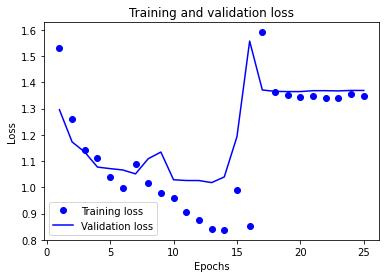

In [76]:
acc = history_dict['sparse_categorical_accuracy']
val_acc = history_dict['val_sparse_categorical_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

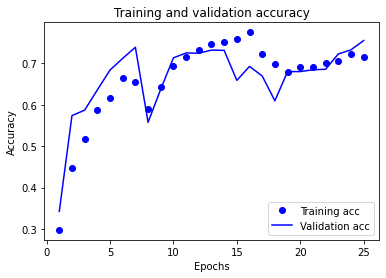

In [77]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()